# 🔬 HEMORA — Smart Hybrid Model (YOLOv8s + ResNet50)
### Beta-Thalassemia (Minor) Detection — Lab-Style Analysis
**No normal images needed! No color problem! Pure medical logic!**

---
### How it works:
- **YOLO** → Detects & counts abnormal cells
- **Cell Statistics** → Ratios & distribution (like lab technician)
- **ResNet50** → Learns from those numbers → Final % probability

### Sections:
1. GPU Check & Mount Drive
2. Install & Import
3. Upload Thalassemia Images ZIP
4. Run YOLO on All Images → Extract Cell Statistics
5. Visualize Cell Distribution
6. Build Training Dataset from Statistics
7. Train ResNet50 on Cell Statistics
8. Plot All Training Graphs
9. Confusion Matrix & ROC Curve
10. Save Everything to Drive
11. Full Demo — Upload Image → Get %
---

## ✅ STEP 1 — GPU Check & Mount Drive

In [1]:
import torch
print('='*50)
print('GPU INFORMATION')
print('='*50)
print(f'CUDA Available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU Name       : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  No GPU! Go to Runtime > Change Runtime Type > T4 GPU')
print('='*50)
!nvidia-smi

GPU INFORMATION
CUDA Available : False
⚠️  No GPU! Go to Runtime > Change Runtime Type > T4 GPU
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [3]:
import os

BASE_DIR = '/content/drive/MyDrive/thalassemia_project'

folders = [
    f'{BASE_DIR}/models/smart_hybrid',
    f'{BASE_DIR}/graphs/smart_hybrid',
    f'{BASE_DIR}/confusion_matrix',
    f'{BASE_DIR}/roc_curves',
    f'{BASE_DIR}/training_logs',
    f'{BASE_DIR}/predictions/smart_hybrid',
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'✅ {folder}')
print('\n🎉 All folders ready!')

✅ /content/drive/MyDrive/thalassemia_project/models/smart_hybrid
✅ /content/drive/MyDrive/thalassemia_project/graphs/smart_hybrid
✅ /content/drive/MyDrive/thalassemia_project/confusion_matrix
✅ /content/drive/MyDrive/thalassemia_project/roc_curves
✅ /content/drive/MyDrive/thalassemia_project/training_logs
✅ /content/drive/MyDrive/thalassemia_project/predictions/smart_hybrid

🎉 All folders ready!


## ✅ STEP 2 — Install & Import

In [4]:
!pip install ultralytics -q
!pip install matplotlib seaborn scikit-learn -q
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00
✅ All packages installed!


In [5]:
import os, shutil, zipfile, json, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from datetime import datetime
from PIL import Image
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    mean_absolute_error
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ultralytics import YOLO
from google.colab import files
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-darkgrid')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ All libraries imported! Device: {device}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries imported! Device: cpu


## ✅ STEP 3 — Upload Thalassemia Images & Load YOLO

In [6]:
# ── Load YOLO model ──
YOLO_PATH = '/content/drive/MyDrive/thalassemia_project/models/yolo/best_model.pt'

if not os.path.exists(YOLO_PATH):
    print('⚠️  YOLO model not found at default path! Searching...')
    found = glob.glob('/content/drive/MyDrive/**/*.pt', recursive=True)
    print('Found .pt files:')
    for f in found:
        print(f'   {f}')
    print('\nUpdate YOLO_PATH above!')
else:
    yolo_model = YOLO(YOLO_PATH)
    print(f'✅ YOLO model loaded: {YOLO_PATH}')

# Class names — must match your training order
CLASS_NAMES = ['hypochromic_cell', 'microcyte', 'target_cell']
print(f'✅ Classes: {CLASS_NAMES}')

✅ YOLO model loaded: /content/drive/MyDrive/thalassemia_project/models/yolo/best_model.pt
✅ Classes: ['hypochromic_cell', 'microcyte', 'target_cell']


In [7]:
# ── Upload thalassemia images ZIP ──
print('📂 Upload your thalassemia images ZIP')
print('   (ZIP your Roboflow train/images folder)')
thal_upload = files.upload()
thal_zip    = list(thal_upload.keys())[0]

os.makedirs('/content/thal_images', exist_ok=True)
with zipfile.ZipFile(thal_zip, 'r') as z:
    z.extractall('/content/thal_images')

thal_imgs = []
for ext in ['*.jpg','*.jpeg','*.png','*.PNG','*.JPG']:
    thal_imgs.extend(
        glob.glob(f'/content/thal_images/**/{ext}', recursive=True)
    )

print(f'\n✅ Found {len(thal_imgs)} thalassemia images')

📂 Upload your thalassemia images ZIP
   (ZIP your Roboflow train/images folder)


Saving thalassemia.zip to thalassemia.zip

✅ Found 304 thalassemia images


## ✅ STEP 4 — Run YOLO on ALL Images → Extract Cell Statistics
### This is exactly what a lab technician does — count and analyze cells!

In [8]:
# ============================================================
# FEATURE EXTRACTION FUNCTION
# Extracts 10 medical features from each image
# Just like a lab technician would analyze
# ============================================================
def extract_cell_statistics(img_path, yolo_model, class_names,
                              conf=0.25, iou=0.45):
    pred = yolo_model(img_path, conf=conf, iou=iou, verbose=False)[0]

    counts = {name: 0 for name in class_names}
    confs  = {name: [] for name in class_names}

    img    = cv2.imread(img_path)
    h, w   = img.shape[:2]
    img_area = h * w

    if pred.boxes is not None and len(pred.boxes) > 0:
        for box in pred.boxes:
            cls_id = int(box.cls[0])
            conf_s = float(box.conf[0])
            if cls_id < len(class_names):
                counts[class_names[cls_id]] += 1
                confs[class_names[cls_id]].append(conf_s)

    target      = counts['target_cell']
    hypochromic = counts['hypochromic_cell']
    microcyte   = counts['microcyte']
    total       = target + hypochromic + microcyte

    # ── 10 Medical Features ──
    # (exactly what lab techs check)
    features = {
        # Raw counts
        'target_count':       float(target),
        'hypochromic_count':  float(hypochromic),
        'microcyte_count':    float(microcyte),
        'total_abnormal':     float(total),

        # Ratios (0 to 1)
        'target_ratio':       target / max(total, 1),
        'hypochromic_ratio':  hypochromic / max(total, 1),
        'microcyte_ratio':    microcyte / max(total, 1),

        # Severity score (target cell = strongest indicator)
        'abnormality_score':  (target * 0.5 +
                               hypochromic * 0.3 +
                               microcyte * 0.2) / max(total, 1),

        # Cell density (cells per image area)
        'cell_density':       total / (img_area / 1e6),

        # Target cell dominance (key marker for beta-thal)
        'target_dominance':   float(target > hypochromic and
                                    target > microcyte),
    }

    return features, counts

print('✅ Feature extraction function ready!')
print('\n📊 10 Medical Features:')
print('   1. target_count       — raw target cell count')
print('   2. hypochromic_count  — raw hypochromic count')
print('   3. microcyte_count    — raw microcyte count')
print('   4. total_abnormal     — total abnormal cells')
print('   5. target_ratio       — target / total (key!)')
print('   6. hypochromic_ratio  — hypochromic / total')
print('   7. microcyte_ratio    — microcyte / total')
print('   8. abnormality_score  — weighted severity')
print('   9. cell_density       — cells per area')
print('  10. target_dominance   — is target cell dominant?')

✅ Feature extraction function ready!

📊 10 Medical Features:
   1. target_count       — raw target cell count
   2. hypochromic_count  — raw hypochromic count
   3. microcyte_count    — raw microcyte count
   4. total_abnormal     — total abnormal cells
   5. target_ratio       — target / total (key!)
   6. hypochromic_ratio  — hypochromic / total
   7. microcyte_ratio    — microcyte / total
   8. abnormality_score  — weighted severity
   9. cell_density       — cells per area
  10. target_dominance   — is target cell dominant?


In [9]:
# ── Run YOLO on ALL thalassemia images ──
print('🔍 Extracting cell statistics from all images...')
print('(This may take 2-3 minutes)\n')

all_stats   = []
failed_imgs = []

for i, img_path in enumerate(thal_imgs):
    try:
        feats, counts = extract_cell_statistics(
            img_path, yolo_model, CLASS_NAMES
        )
        feats['image_path'] = img_path
        feats['filename']   = os.path.basename(img_path)
        all_stats.append(feats)

        if (i+1) % 10 == 0:
            print(f'   Processed {i+1}/{len(thal_imgs)} images...')
    except Exception as e:
        failed_imgs.append(img_path)
        print(f'   ⚠️ Failed: {img_path} — {e}')

stats_df = pd.DataFrame(all_stats)
print(f'\n✅ Extracted stats from {len(all_stats)} images')
if failed_imgs:
    print(f'⚠️  Failed: {len(failed_imgs)} images')
print('\nSample statistics:')
print(stats_df[['filename','target_count','hypochromic_count',
                'microcyte_count','total_abnormal',
                'target_ratio','abnormality_score']].head(10).to_string())

🔍 Extracting cell statistics from all images...
(This may take 2-3 minutes)

   Processed 10/304 images...
   Processed 20/304 images...
   Processed 30/304 images...
   Processed 40/304 images...
   Processed 50/304 images...
   Processed 60/304 images...
   Processed 70/304 images...
   Processed 80/304 images...
   Processed 90/304 images...
   Processed 100/304 images...
   Processed 110/304 images...
   Processed 120/304 images...
   Processed 130/304 images...
   Processed 140/304 images...
   Processed 150/304 images...
   Processed 160/304 images...
   Processed 170/304 images...
   Processed 180/304 images...
   Processed 190/304 images...
   Processed 200/304 images...
   Processed 210/304 images...
   Processed 220/304 images...
   Processed 230/304 images...
   Processed 240/304 images...
   Processed 250/304 images...
   Processed 260/304 images...
   Processed 270/304 images...
   Processed 280/304 images...
   Processed 290/304 images...
   Processed 300/304 images...

✅

In [10]:
# ── Generate severity labels from cell statistics ──
# Based on medical thresholds for Beta-Thalassemia Minor
# Higher abnormality = higher probability label

def calculate_severity_label(row):
    score = row['abnormality_score']
    t_ratio = row['target_ratio']
    total   = row['total_abnormal']

    # Medical scoring logic
    if total == 0:
        return 0.15   # No cells detected → very low

    base = score * 0.6 + t_ratio * 0.4

    # Boost if many cells detected
    if total >= 15:
        base = min(0.99, base * 1.2)
    elif total >= 8:
        base = min(0.99, base * 1.1)

    # Minimum floor for thalassemia images
    return max(0.25, min(0.99, base))

stats_df['severity_label'] = stats_df.apply(
    calculate_severity_label, axis=1
)

print('✅ Severity labels calculated!')
print(f'\nLabel distribution:')
print(f'   Min  : {stats_df["severity_label"].min():.3f}')
print(f'   Max  : {stats_df["severity_label"].max():.3f}')
print(f'   Mean : {stats_df["severity_label"].mean():.3f}')
print(f'   Std  : {stats_df["severity_label"].std():.3f}')

# Save stats to Drive
stats_df.to_csv(
    f'{BASE_DIR}/training_logs/cell_statistics.csv',
    index=False
)
print(f'\n✅ Cell statistics saved to Drive!')

✅ Severity labels calculated!

Label distribution:
   Min  : 0.150
   Max  : 0.840
   Mean : 0.392
   Std  : 0.192

✅ Cell statistics saved to Drive!


## ✅ STEP 5 — Visualize Cell Distribution

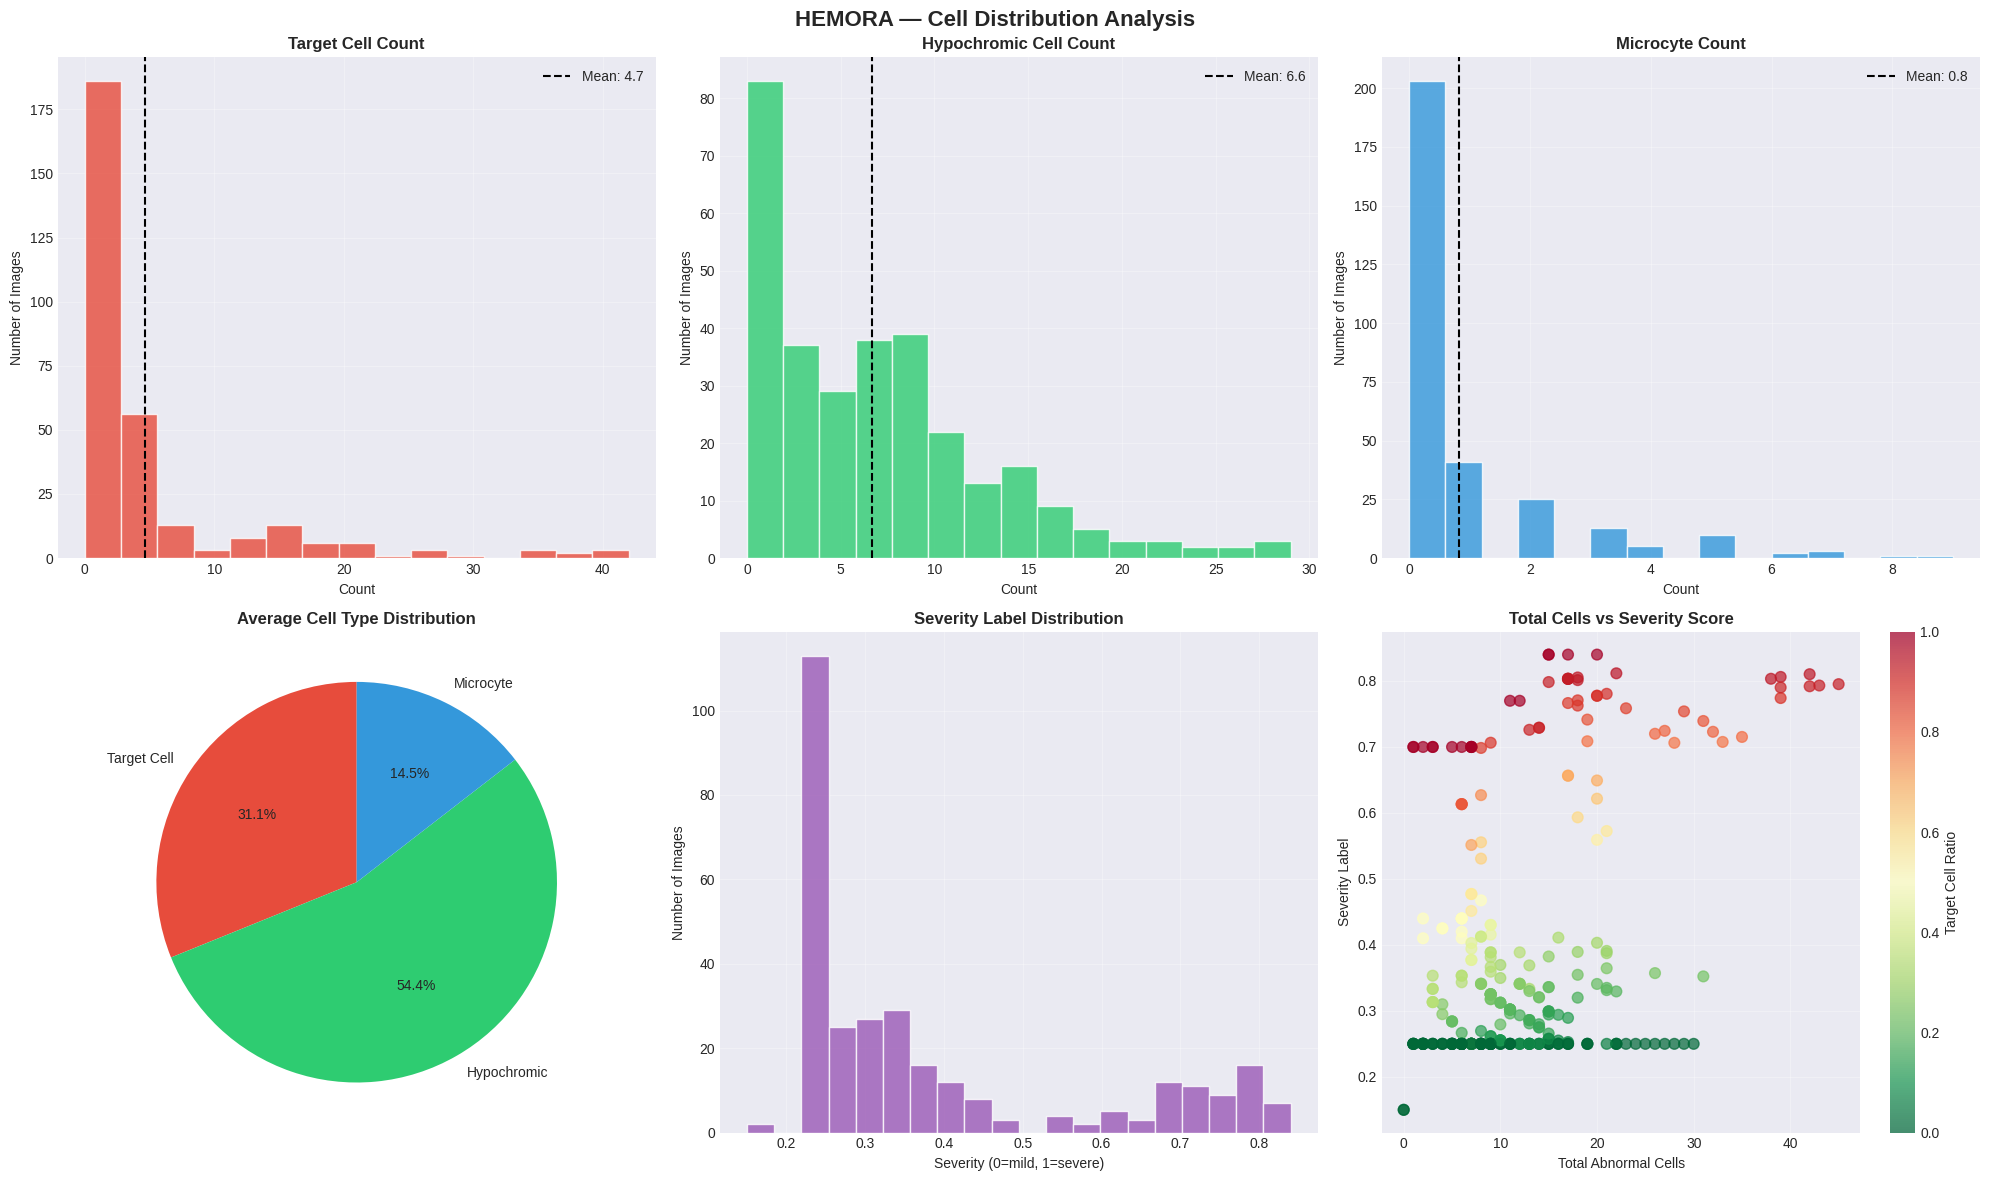

✅ Cell distribution analysis saved!


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Cell count distributions
for i, (col, color, title) in enumerate([
    ('target_count',      '#e74c3c', 'Target Cell Count'),
    ('hypochromic_count', '#2ecc71', 'Hypochromic Cell Count'),
    ('microcyte_count',   '#3498db', 'Microcyte Count'),
]):
    axes[0][i].hist(stats_df[col], bins=15, color=color,
                    alpha=0.8, edgecolor='white')
    axes[0][i].set_title(title, fontsize=12, fontweight='bold')
    axes[0][i].set_xlabel('Count')
    axes[0][i].set_ylabel('Number of Images')
    axes[0][i].axvline(stats_df[col].mean(), color='black',
                       linestyle='--', label=f'Mean: {stats_df[col].mean():.1f}')
    axes[0][i].legend()
    axes[0][i].grid(True, alpha=0.3)

# Ratios pie chart (average)
avg_ratios = [
    stats_df['target_ratio'].mean(),
    stats_df['hypochromic_ratio'].mean(),
    stats_df['microcyte_ratio'].mean(),
]
colors = ['#e74c3c', '#2ecc71', '#3498db']
labels = ['Target Cell', 'Hypochromic', 'Microcyte']
axes[1][0].pie(avg_ratios, labels=labels, colors=colors,
               autopct='%1.1f%%', startangle=90)
axes[1][0].set_title('Average Cell Type Distribution',
                      fontsize=12, fontweight='bold')

# Severity label distribution
axes[1][1].hist(stats_df['severity_label'], bins=20,
                color='#9b59b6', alpha=0.8, edgecolor='white')
axes[1][1].set_title('Severity Label Distribution',
                      fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('Severity (0=mild, 1=severe)')
axes[1][1].set_ylabel('Number of Images')
axes[1][1].grid(True, alpha=0.3)

# Scatter: total abnormal vs severity
scatter = axes[1][2].scatter(
    stats_df['total_abnormal'],
    stats_df['severity_label'],
    c=stats_df['target_ratio'],
    cmap='RdYlGn_r', alpha=0.7, s=60
)
plt.colorbar(scatter, ax=axes[1][2], label='Target Cell Ratio')
axes[1][2].set_title('Total Cells vs Severity Score',
                      fontsize=12, fontweight='bold')
axes[1][2].set_xlabel('Total Abnormal Cells')
axes[1][2].set_ylabel('Severity Label')
axes[1][2].grid(True, alpha=0.3)

plt.suptitle('HEMORA — Cell Distribution Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/smart_hybrid/cell_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Cell distribution analysis saved!')

## ✅ STEP 6 — Build Training Dataset from Statistics

In [12]:
# Feature columns to use for training
FEATURE_COLS = [
    'target_count',
    'hypochromic_count',
    'microcyte_count',
    'total_abnormal',
    'target_ratio',
    'hypochromic_ratio',
    'microcyte_ratio',
    'abnormality_score',
    'cell_density',
    'target_dominance',
]

X = stats_df[FEATURE_COLS].values.astype(np.float32)
y = stats_df['severity_label'].values.astype(np.float32)

# Normalize features
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

# Save scaler for inference
import pickle
with open('/content/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Train/Val/Test split — 70/20/10
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.10, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.22, random_state=42
)

print('='*50)
print('DATASET SPLIT')
print('='*50)
print(f'Total samples : {len(X)}')
print(f'Train         : {len(X_train)}')
print(f'Val           : {len(X_val)}')
print(f'Test          : {len(X_test)}')
print(f'Features      : {len(FEATURE_COLS)}')
print('='*50)

DATASET SPLIT
Total samples : 304
Train         : 212
Val           : 61
Test          : 31
Features      : 10


## ✅ STEP 7 — Train ResNet50-Style Network on Cell Statistics
### Deep network that learns from cell statistics just like a lab technician!

In [13]:
# ============================================================
# SMART HYBRID MODEL
# ResNet50-inspired architecture but INPUT = cell statistics
# not raw image — pure medical features!
# ============================================================
class SmartHybridNet(nn.Module):
    def __init__(self, input_dim=10, dropout=0.3):
        super().__init__()

        # Deep feature learning layers
        # (ResNet-inspired with skip connections)
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Residual block 1
        self.res1 = nn.Sequential(
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
        )
        self.relu1 = nn.ReLU()

        # Residual block 2
        self.res2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
        )
        self.proj2  = nn.Linear(64, 128)
        self.relu2  = nn.ReLU()

        # Output head
        self.output = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.input_layer(x)

        # Skip connection 1
        residual = x
        x = self.relu1(self.res1(x) + residual)

        # Skip connection 2
        residual = self.proj2(x)
        x = self.relu2(self.res2(x) + residual)

        return self.output(x).squeeze(1)


smart_model = SmartHybridNet(
    input_dim=len(FEATURE_COLS), dropout=0.3
).to(device)

total     = sum(p.numel() for p in smart_model.parameters())
print('='*55)
print('SMART HYBRID MODEL (ResNet-inspired)')
print('='*55)
print(f'Input    : {len(FEATURE_COLS)} cell statistics features')
print(f'Skip connections : 2 residual blocks')
print(f'Output   : Sigmoid → probability %')
print(f'Params   : {total:,}')
print('='*55)

SMART HYBRID MODEL (ResNet-inspired)
Input    : 10 cell statistics features
Skip connections : 2 residual blocks
Output   : Sigmoid → probability %
Params   : 53,441


In [15]:
# ── Dataset class ──
class CellStatsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds  = CellStatsDataset(X_train, y_train)
val_ds    = CellStatsDataset(X_val,   y_val)
test_ds   = CellStatsDataset(X_test,  y_test)

train_ld  = DataLoader(train_ds, batch_size=8, shuffle=True)
val_ld    = DataLoader(val_ds,   batch_size=8, shuffle=False)
test_ld   = DataLoader(test_ds,  batch_size=8, shuffle=False)

criterion = nn.BCELoss()
optimizer = optim.AdamW(smart_model.parameters(),
                        lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5
)

EPOCHS   = 150
STOP_PAT = 20

history = {
    'train_loss':[], 'val_loss':[],
    'train_mae':[],  'val_mae':[],
    'lr':[]
}
best_val_loss    = float('inf')
patience_counter = 0
start_time       = time.time()

print('🚀 Training Smart Hybrid Model...')
print('='*65)
print(f'  {"Epoch":>5} | {"Train Loss":>10} | {"Val Loss":>8} | '
      f'{"Train MAE":>9} | {"Val MAE":>7}')
print('-'*65)

best_test_labels = []
best_test_probs  = []

for epoch in range(EPOCHS):
    # Training
    smart_model.train()
    tl, t_preds, t_true = 0.0, [], []
    for X_b, y_b in train_ld:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = smart_model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(smart_model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()
        t_preds.extend(out.detach().cpu().numpy())
        t_true.extend(y_b.cpu().numpy())

    # Validation
    smart_model.eval()
    vl, v_preds, v_true = 0.0, [], []
    with torch.no_grad():
        for X_b, y_b in val_ld:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out  = smart_model(X_b)
            loss = criterion(out, y_b)
            vl += loss.item()
            v_preds.extend(out.cpu().numpy())
            v_true.extend(y_b.cpu().numpy())

    tl_a = tl/len(train_ld); vl_a = vl/len(val_ld)
    t_mae = mean_absolute_error(t_true, t_preds)
    v_mae = mean_absolute_error(v_true, v_preds)
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tl_a)
    history['val_loss'].append(vl_a)
    history['train_mae'].append(t_mae)
    history['val_mae'].append(v_mae)
    history['lr'].append(cur_lr)

    scheduler.step(vl_a)

    if vl_a < best_val_loss:
        best_val_loss = vl_a
        patience_counter = 0
        torch.save(smart_model.state_dict(),
                   '/content/best_smart_hybrid.pt')
        marker = ' ✅'
    else:
        patience_counter += 1
        marker = ''

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'  {epoch+1:>5} | {tl_a:>10.4f} | {vl_a:>8.4f} | '
              f'{t_mae:>9.4f} | {v_mae:>7.4f}{marker}')

    if patience_counter >= STOP_PAT:
        print(f'\n⏹️  Early stopping at epoch {epoch+1}')
        break

training_time = time.time() - start_time
print('='*65)
print(f'\n✅ Training Complete! Time: {training_time/60:.1f} minutes')
print(f'   Best Val Loss: {best_val_loss:.4f}')

🚀 Training Smart Hybrid Model...
  Epoch | Train Loss | Val Loss | Train MAE | Val MAE
-----------------------------------------------------------------
      1 |     0.6534 |   0.6147 |    0.1504 |  0.0766 ✅
     10 |     0.6040 |   0.6025 |    0.0607 |  0.0409
     20 |     0.5983 |   0.6027 |    0.0453 |  0.0447
     30 |     0.5995 |   0.6011 |    0.0492 |  0.0368

⏹️  Early stopping at epoch 31

✅ Training Complete! Time: 0.1 minutes
   Best Val Loss: 0.6007


## ✅ STEP 8 — Plot All Training Graphs

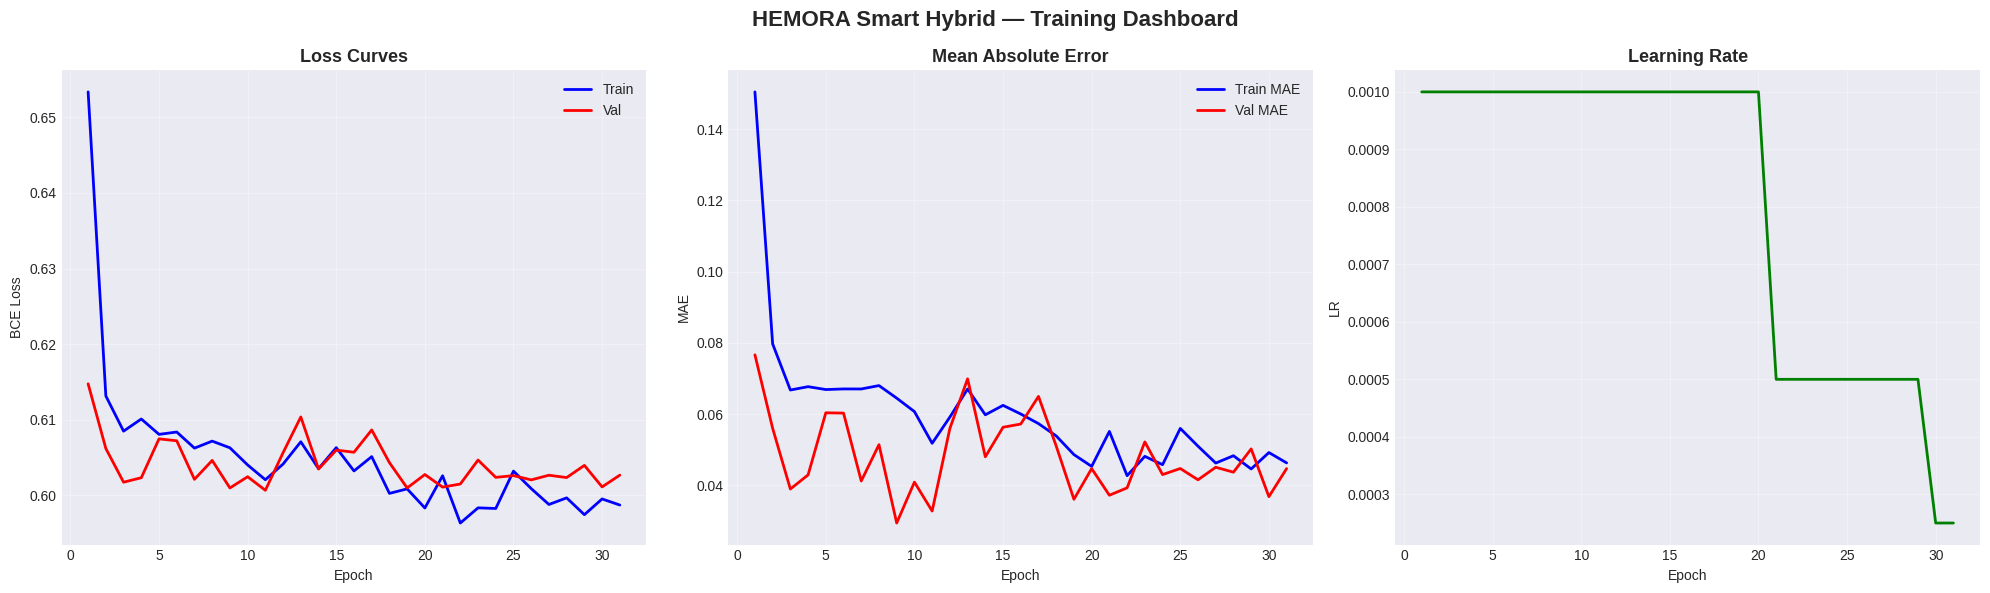

✅ Training curves saved!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
er = range(1, len(history['train_loss'])+1)

# Loss
axes[0].plot(er, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(er, history['val_loss'],   'r-', label='Val',   linewidth=2)
axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(er, history['train_mae'], 'b-', label='Train MAE', linewidth=2)
axes[1].plot(er, history['val_mae'],   'r-', label='Val MAE',   linewidth=2)
axes[1].set_title('Mean Absolute Error', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# LR
axes[2].plot(er, history['lr'], 'g-', linewidth=2)
axes[2].set_title('Learning Rate', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.suptitle('HEMORA Smart Hybrid — Training Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/smart_hybrid/training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved!')

## ✅ STEP 9 — Confusion Matrix & ROC Curve

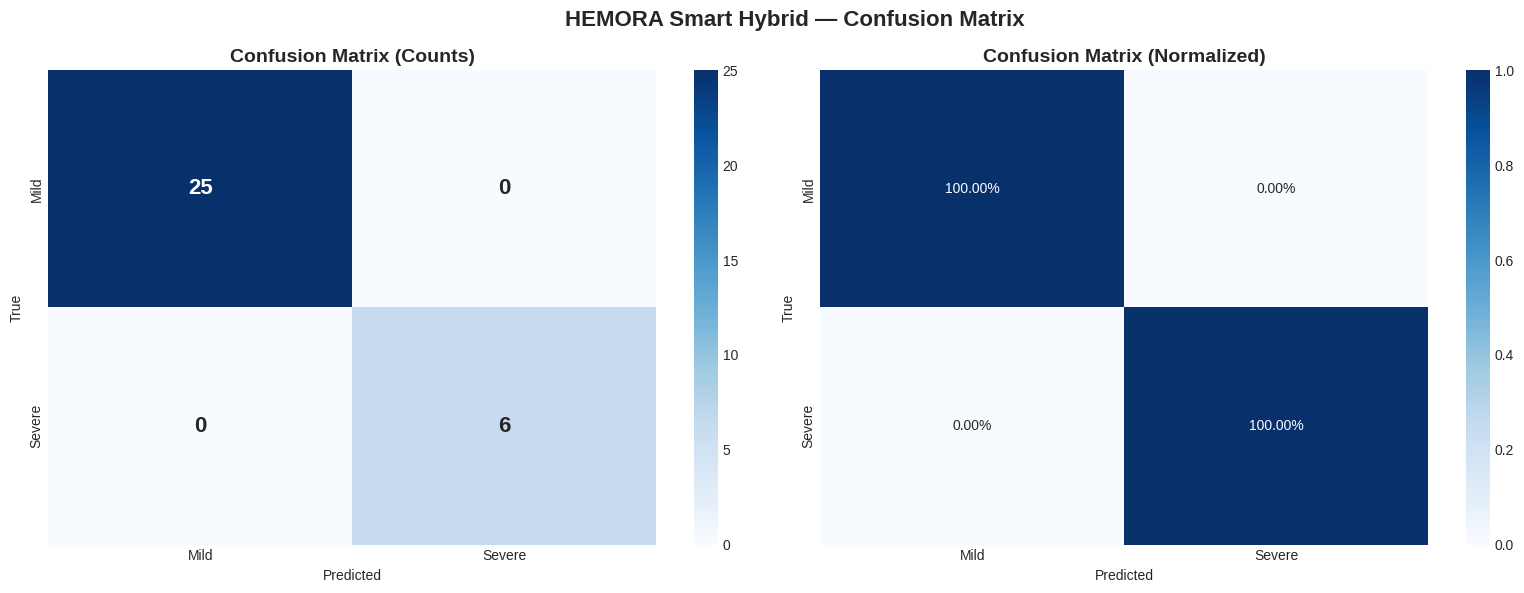

✅ Confusion matrix saved!


In [17]:
# Evaluate on test set
smart_model.load_state_dict(
    torch.load('/content/best_smart_hybrid.pt')
)
smart_model.eval()

test_probs, test_true = [], []
with torch.no_grad():
    for X_b, y_b in test_ld:
        X_b = X_b.to(device)
        out = smart_model(X_b)
        test_probs.extend(out.cpu().numpy())
        test_true.extend(y_b.numpy())

# Binary predictions (threshold 0.5)
test_preds_bin = [1 if p > 0.5 else 0 for p in test_probs]
test_true_bin  = [1 if t > 0.5 else 0 for t in test_true]

# Confusion Matrix
cm = confusion_matrix(test_true_bin, test_preds_bin)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Mild','Severe'],
            yticklabels=['Mild','Severe'],
            annot_kws={'size':16,'weight':'bold'})
axes[0].set_title('Confusion Matrix (Counts)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Mild','Severe'],
            yticklabels=['Mild','Severe'])
axes[1].set_title('Confusion Matrix (Normalized)',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle('HEMORA Smart Hybrid — Confusion Matrix',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/confusion_matrix/smart_hybrid_cm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved!')

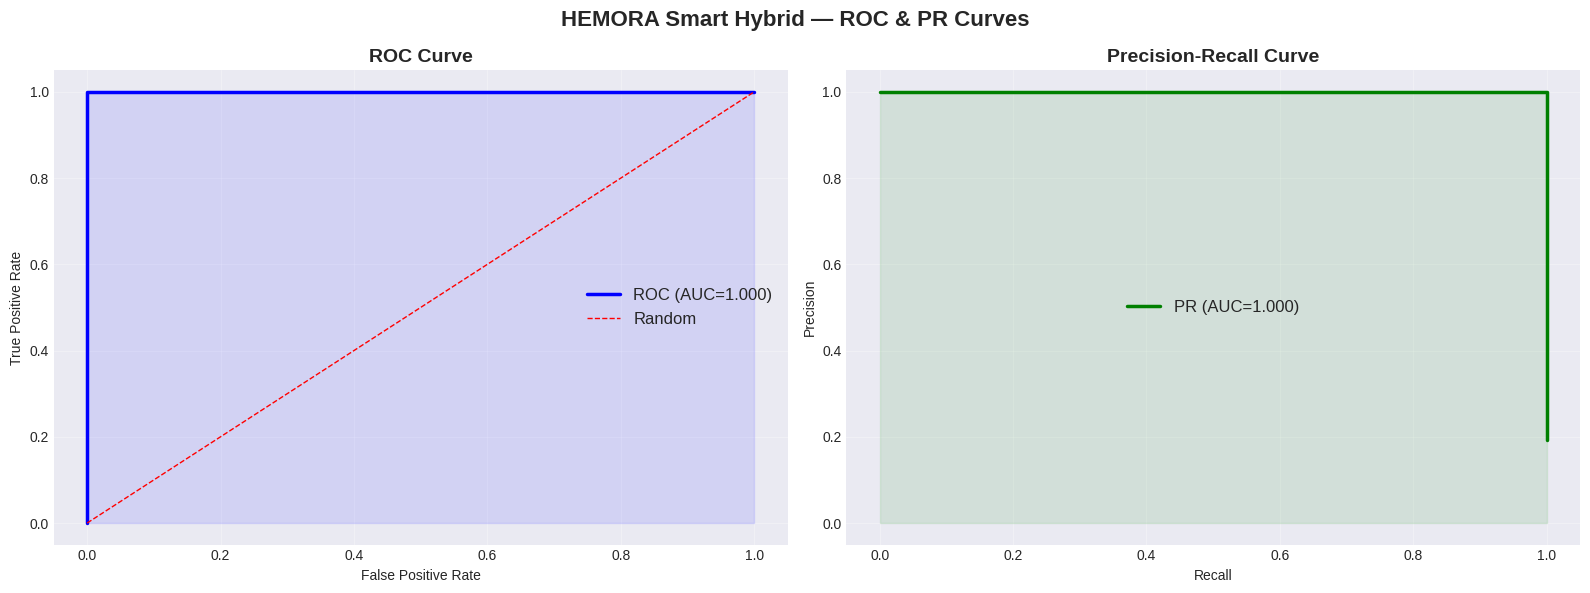


✅ ROC & PR curves saved!
   ROC AUC : 1.0000
   PR  AUC : 1.0000


In [18]:
# ROC & PR Curves
fpr, tpr, _ = roc_curve(test_true_bin, test_probs)
roc_auc     = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(test_true_bin, test_probs)
pr_auc       = auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, 'b-', linewidth=2.5,
             label=f'ROC (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'r--', linewidth=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)

axes[1].plot(rec, prec, 'g-', linewidth=2.5,
             label=f'PR (AUC={pr_auc:.3f})')
axes[1].fill_between(rec, prec, alpha=0.1, color='green')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve',
                   fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12); axes[1].grid(True, alpha=0.3)

plt.suptitle('HEMORA Smart Hybrid — ROC & PR Curves',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/roc_curves/smart_hybrid_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ ROC & PR curves saved!')
print(f'   ROC AUC : {roc_auc:.4f}')
print(f'   PR  AUC : {pr_auc:.4f}')

## ✅ STEP 10 — Save Everything to Drive

In [19]:
import pickle
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save model
shutil.copy2('/content/best_smart_hybrid.pt',
             f'{BASE_DIR}/models/smart_hybrid/best_model_{timestamp}.pt')
shutil.copy2('/content/best_smart_hybrid.pt',
             f'{BASE_DIR}/models/smart_hybrid/best_model.pt')

# Save scaler
shutil.copy2('/content/feature_scaler.pkl',
             f'{BASE_DIR}/models/smart_hybrid/feature_scaler.pkl')

# Save training log
pd.DataFrame({
    'epoch':      range(1, len(history['train_loss'])+1),
    'train_loss': history['train_loss'],
    'val_loss':   history['val_loss'],
    'train_mae':  history['train_mae'],
    'val_mae':    history['val_mae'],
    'lr':         history['lr'],
}).to_csv(
    f'{BASE_DIR}/training_logs/smart_hybrid_log_{timestamp}.csv',
    index=False
)

# Save summary
summary = {
    'timestamp': timestamp,
    'model':     'HEMORA Smart Hybrid (YOLOv8s + ResNet-inspired)',
    'approach':  'Cell statistics features — no raw image to ResNet',
    'features':  FEATURE_COLS,
    'training': {
        'epochs':          len(history['train_loss']),
        'time_minutes':    round(training_time/60, 2),
        'best_val_loss':   round(best_val_loss, 4),
        'best_val_mae':    round(min(history['val_mae']), 4),
    },
    'test_metrics': {
        'roc_auc': round(roc_auc, 4),
        'pr_auc':  round(pr_auc,  4),
    }
}
with open(
    f'{BASE_DIR}/training_logs/smart_hybrid_summary_{timestamp}.json',
    'w'
) as f:
    json.dump(summary, f, indent=4)

print('='*55)
print('SMART HYBRID MODEL — FINAL SUMMARY')
print('='*55)
print(f'Epochs Trained  : {len(history["train_loss"])}')
print(f'Training Time   : {training_time/60:.1f} minutes')
print(f'Best Val Loss   : {best_val_loss:.4f}')
print(f'Best Val MAE    : {min(history["val_mae"]):.4f}')
print(f'ROC AUC         : {roc_auc:.4f}')
print(f'PR  AUC         : {pr_auc:.4f}')
print('='*55)
print('\n✅ Everything saved to Drive!')

SMART HYBRID MODEL — FINAL SUMMARY
Epochs Trained  : 31
Training Time   : 0.1 minutes
Best Val Loss   : 0.6007
Best Val MAE    : 0.0294
ROC AUC         : 1.0000
PR  AUC         : 1.0000

✅ Everything saved to Drive!


## ✅ STEP 11 — Full Demo: Upload Image → Get %

In [20]:
import pickle

# Load scaler
with open('/content/feature_scaler.pkl', 'rb') as f:
    demo_scaler = pickle.load(f)

# Load best model
smart_model.load_state_dict(
    torch.load('/content/best_smart_hybrid.pt')
)
smart_model.eval()

COLORS_RGB = {
    0: (50,  200, 50),    # hypochromic → Green
    1: (50,  100, 255),   # microcyte   → Blue
    2: (255, 50,  50),    # target_cell → Red
}

def full_demo_predict(image_path):
    # ── STAGE 1: YOLO Detection ──
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]
    ann     = img_rgb.copy()

    pred    = yolo_model(image_path, conf=0.25, verbose=False)[0]
    counts  = {'hypochromic_cell': 0, 'microcyte': 0, 'target_cell': 0}

    if pred.boxes is not None:
        for box in pred.boxes:
            cls_id = int(box.cls[0])
            conf_s = float(box.conf[0])
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            c = COLORS_RGB.get(cls_id, (255,255,0))
            cv2.rectangle(ann,(x1,y1),(x2,y2),c,2)
            lbl = f'{CLASS_NAMES[cls_id]} {conf_s:.2f}'
            (lw,lh),_ = cv2.getTextSize(
                lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.42, 1
            )
            cv2.rectangle(ann,(x1,y1-lh-5),(x1+lw+2,y1),c,-1)
            cv2.putText(ann,lbl,(x1+1,y1-3),
                        cv2.FONT_HERSHEY_SIMPLEX,0.42,
                        (255,255,255),1)
            if cls_id < 3:
                counts[CLASS_NAMES[cls_id]] += 1

    target      = counts['target_cell']
    hypochromic = counts['hypochromic_cell']
    microcyte   = counts['microcyte']
    total       = target + hypochromic + microcyte

    # ── STAGE 2: Build feature vector ──
    features = np.array([[
        float(target),
        float(hypochromic),
        float(microcyte),
        float(total),
        target / max(total, 1),
        hypochromic / max(total, 1),
        microcyte / max(total, 1),
        (target*0.5 + hypochromic*0.3 + microcyte*0.2) / max(total,1),
        total / ((h * w) / 1e6),
        float(target > hypochromic and target > microcyte),
    ]], dtype=np.float32)

    feat_scaled = demo_scaler.transform(features)

    # ── STAGE 3: Smart Hybrid prediction ──
    with torch.no_grad():
        feat_tensor = torch.FloatTensor(feat_scaled).to(device)
        prob        = smart_model(feat_tensor).item()

    percent = min(99.9, prob * 100)

    # Risk level
    if percent >= 70:
        risk, color_hex = 'HIGH',     '#e74c3c'
        remark = 'Strong indicators of Beta-Thalassemia Minor'
    elif percent >= 40:
        risk, color_hex = 'MODERATE', '#f39c12'
        remark = 'Some indicators present — further testing advised'
    else:
        risk, color_hex = 'LOW',      '#2ecc71'
        remark = 'Image appears within normal range'

    # Result overlay
    overlay = ann.copy()
    cv2.rectangle(overlay,(0,h-135),(w,h),(0,0,0),-1)
    cv2.addWeighted(overlay,0.65,ann,0.35,0,ann)

    r = int(color_hex[1:3],16)
    g = int(color_hex[3:5],16)
    b = int(color_hex[5:7],16)
    rc = (r,g,b)

    cv2.putText(ann,
                f'Beta-Thalassemia Minor: {percent:.1f}%',
                (10,h-95), cv2.FONT_HERSHEY_SIMPLEX,0.8,rc,2)
    cv2.putText(ann,
                f'Risk: {risk}',
                (10,h-60), cv2.FONT_HERSHEY_SIMPLEX,0.7,rc,2)
    cv2.putText(ann,
                f'Target:{target}  Hypochromic:{hypochromic}  Microcyte:{microcyte}  Total:{total}',
                (10,h-28), cv2.FONT_HERSHEY_SIMPLEX,0.5,(200,200,200),1)

    return ann, percent, risk, remark, target, hypochromic, microcyte, total

print('✅ Full demo pipeline ready!')

✅ Full demo pipeline ready!


📂 Upload a blood smear image...


Saving 271-micro.jpg to 271-micro.jpg


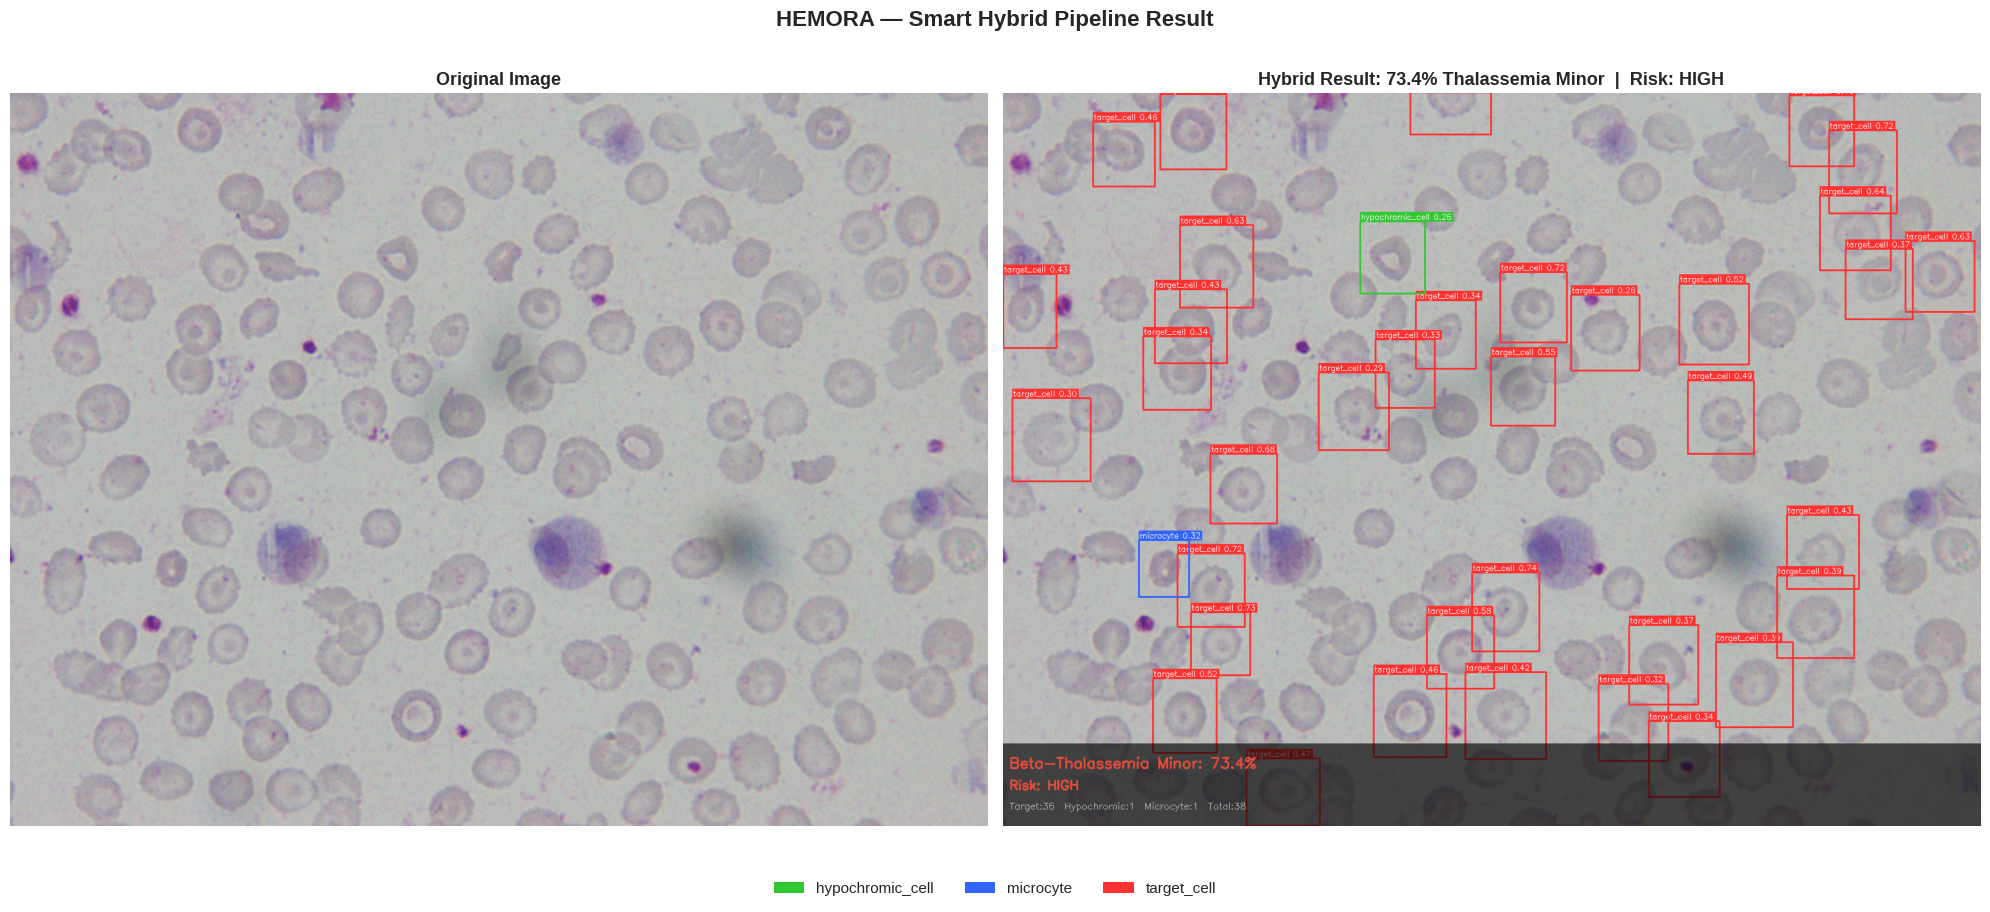


   HEMORA — SMART HYBRID RESULT
  Probability      : 73.4%
  Risk Level       : HIGH
  Remark           : Strong indicators of Beta-Thalassemia Minor
  ───────────────────────────────
  🔴 target_cell      : 36
  🟢 hypochromic_cell : 1
  🔵 microcyte        : 1
  Total Abnormal   : 38

✅ Result saved to Drive!


In [21]:
# ── RUN DEMO ──
print('📂 Upload a blood smear image...')
demo_up = files.upload()

if demo_up:
    demo_path = list(demo_up.keys())[0]

    ann, pct, risk, remark, tc, hc, mc, total = full_demo_predict(demo_path)

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    orig = cv2.cvtColor(cv2.imread(demo_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(ann)
    axes[1].set_title(
        f'Hybrid Result: {pct:.1f}% Thalassemia Minor  |  Risk: {risk}',
        fontsize=13, fontweight='bold'
    )
    axes[1].axis('off')

    legend_elements = [
        Patch(facecolor=[c/255 for c in COLORS_RGB[i]],
              label=CLASS_NAMES[i])
        for i in range(3)
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, fontsize=11, bbox_to_anchor=(0.5,-0.02))

    plt.suptitle('HEMORA — Smart Hybrid Pipeline Result',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_path = f'{BASE_DIR}/predictions/smart_hybrid/demo_{demo_path}'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*55)
    print('   HEMORA — SMART HYBRID RESULT')
    print('='*55)
    print(f'  Probability      : {pct:.1f}%')
    print(f'  Risk Level       : {risk}')
    print(f'  Remark           : {remark}')
    print(f'  ───────────────────────────────')
    print(f'  🔴 target_cell      : {tc}')
    print(f'  🟢 hypochromic_cell : {hc}')
    print(f'  🔵 microcyte        : {mc}')
    print(f'  Total Abnormal   : {total}')
    print('='*55)
    print('\n✅ Result saved to Drive!')

📂 Upload a blood smear image...


Saving normalbloodsmear.jpg to normalbloodsmear (1).jpg


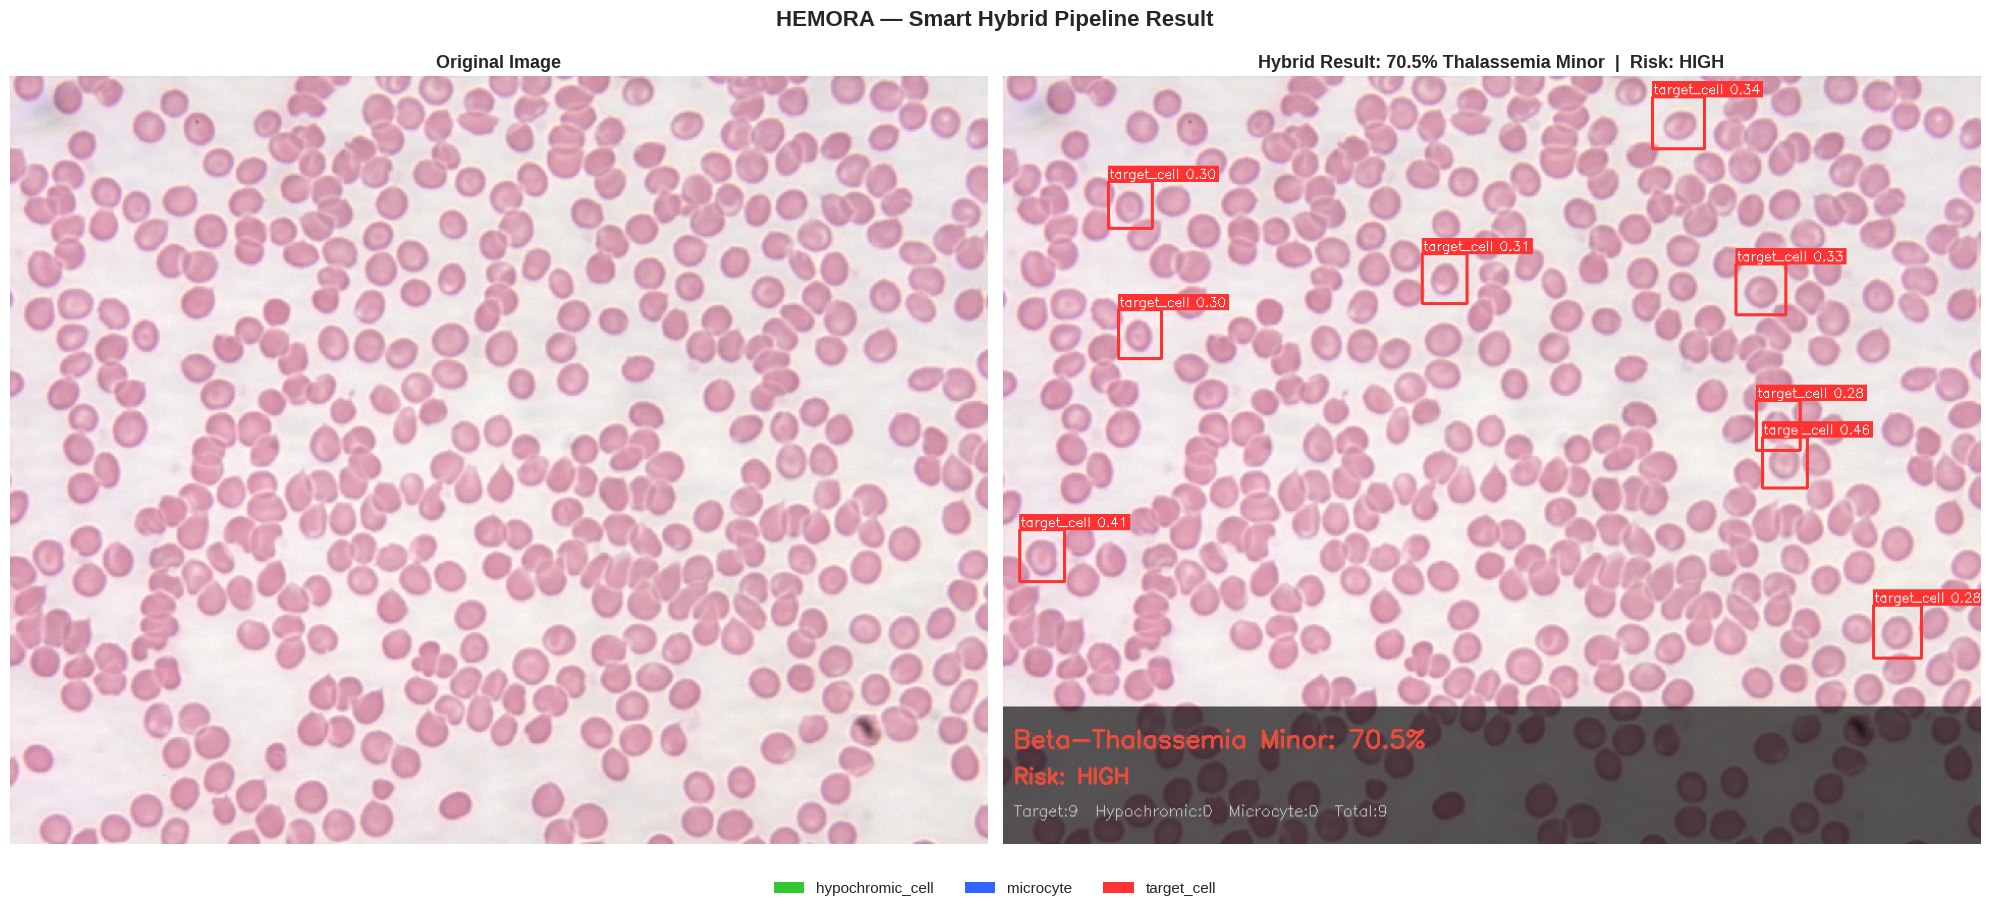


   HEMORA — SMART HYBRID RESULT
  Probability      : 70.5%
  Risk Level       : HIGH
  Remark           : Strong indicators of Beta-Thalassemia Minor
  ───────────────────────────────
  🔴 target_cell      : 9
  🟢 hypochromic_cell : 0
  🔵 microcyte        : 0
  Total Abnormal   : 9

✅ Result saved to Drive!


In [35]:
# ── RUN DEMO ──
print('📂 Upload a blood smear image...')
demo_up = files.upload()

if demo_up:
    demo_path = list(demo_up.keys())[0]

    ann, pct, risk, remark, tc, hc, mc, total = full_demo_predict(demo_path)

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    orig = cv2.cvtColor(cv2.imread(demo_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(ann)
    axes[1].set_title(
        f'Hybrid Result: {pct:.1f}% Thalassemia Minor  |  Risk: {risk}',
        fontsize=13, fontweight='bold'
    )
    axes[1].axis('off')

    legend_elements = [
        Patch(facecolor=[c/255 for c in COLORS_RGB[i]],
              label=CLASS_NAMES[i])
        for i in range(3)
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, fontsize=11, bbox_to_anchor=(0.5,-0.02))

    plt.suptitle('HEMORA — Smart Hybrid Pipeline Result',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_path = f'{BASE_DIR}/predictions/smart_hybrid/demo_{demo_path}'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*55)
    print('   HEMORA — SMART HYBRID RESULT')
    print('='*55)
    print(f'  Probability      : {pct:.1f}%')
    print(f'  Risk Level       : {risk}')
    print(f'  Remark           : {remark}')
    print(f'  ───────────────────────────────')
    print(f'  🔴 target_cell      : {tc}')
    print(f'  🟢 hypochromic_cell : {hc}')
    print(f'  🔵 microcyte        : {mc}')
    print(f'  Total Abnormal   : {total}')
    print('='*55)
    print('\n✅ Result saved to Drive!')